# 07 Zoom temporel

Dernières 10 semaines, avant/après Knafo, pics d'anomalies et momentum.

## 7.1 Configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, DATA_RAW, LEGACY_TEMPORAL, A7_OUT, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

replies = load_replies()
tweets = pd.read_csv(DATA_RAW / "tweets_twitter.csv")
weekly = _safe_read(LEGACY_TEMPORAL / "weekly_metrics_twitter.csv")
momentum = _safe_read(LEGACY_TEMPORAL / "momentum_scores.csv")
anomalies = _safe_read(LEGACY_TEMPORAL / "anomalies_detected.csv")

## 7.1 Contexte de la montée

Volume tweets + replies par semaine. Accélération en janvier 2026. Top 3 semaines par interactions.

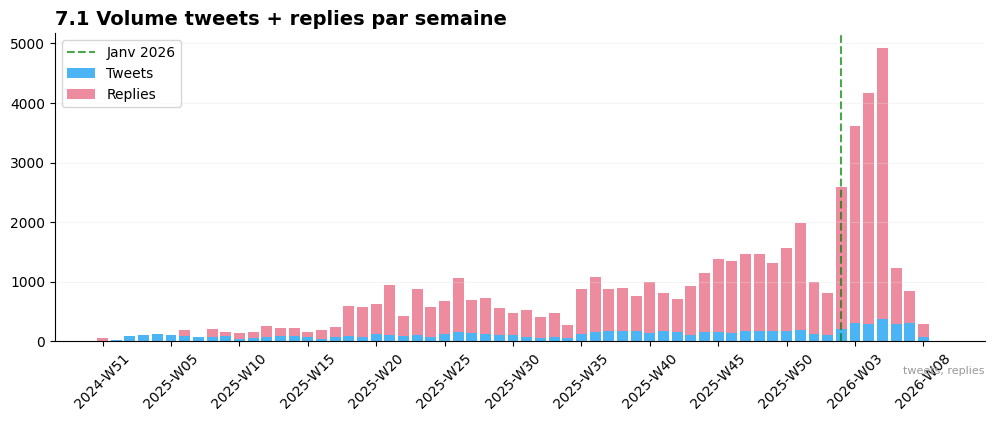

In [11]:
# Volume tweets + replies par semaine
tweets["ts"] = pd.to_datetime(tweets["timestamp"], errors="coerce")
tc = tweets["ts"].dt.isocalendar()
tweets["yw"] = tc["year"].astype(str) + "-W" + tc["week"].astype(str).str.zfill(2)
tw_vol = tweets.groupby("yw").size()
if "year_week" in replies.columns:
    rep_vol = replies.groupby("year_week").size()
else:
    cal = replies["ts_parsed"].dt.isocalendar()
    replies["yw"] = cal["year"].astype(str) + "-W" + cal["week"].astype(str).str.zfill(2)
    rep_vol = replies.groupby("yw").size()
fig, ax = plt.subplots(figsize=(12, 4))
all_weeks = tw_vol.index.union(rep_vol.index)
ax.bar(range(len(all_weeks)), tw_vol.reindex(all_weeks).fillna(0).values, label="Tweets", color="#1DA1F2", alpha=0.8)
ax.bar(range(len(all_weeks)), rep_vol.reindex(all_weeks).fillna(0).values, bottom=tw_vol.reindex(all_weeks).fillna(0).values, label="Replies", color="#E4405F", alpha=0.6)
ax.axvline(len(all_weeks)-8, color="green", ls="--", alpha=0.7, label="Janv 2026")
ax.set_xticks(range(0, len(all_weeks), max(1, len(all_weeks)//12)))
ax.set_xticklabels([all_weeks[i] for i in range(0, len(all_weeks), max(1, len(all_weeks)//12))], rotation=45)
ax.legend()
swiss_style(ax, "7.1 Volume tweets + replies par semaine", source="tweets, replies")
fig.savefig(FIG_DIR / "07_contexte_montee.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 7.2 ER médian sur 10 dernières semaines

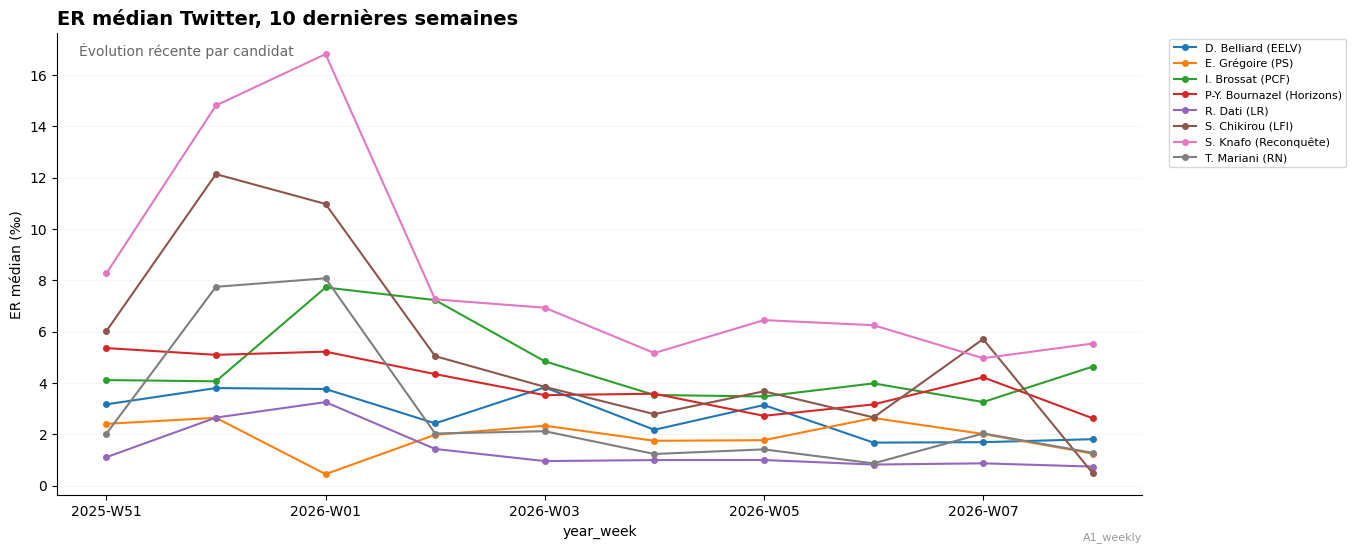

In [12]:
if weekly is not None:
    wk = weekly.copy()
    # er_median est en décimal (0.01 = 10‰) ; colonne er_median_pct absente dans les CSV
    er_col = "er_median_pct" if "er_median_pct" in wk.columns else "er_median"
    wk["er_plot"] = wk[er_col] * 1000 if er_col == "er_median" else wk[er_col]  # en ‰
    wk["yw"] = pd.to_datetime(wk["year_week"] + "-1", format="%Y-W%W-%w", errors="coerce")
    wk = wk.dropna(subset=["yw"]).sort_values("yw")
    last10 = wk.groupby("yw").first().reset_index().tail(10)
    yw_list = last10["yw"].tolist()
    sub = wk[wk["yw"].isin(yw_list)]
    piv = sub.pivot_table(index="year_week", columns="candidate_label", values="er_plot", aggfunc="first")
    piv = piv.reindex(sorted(piv.index, key=lambda x: (x.split("-")[0], x.split("-")[1])))
    fig, ax = plt.subplots(figsize=(14, 6))
    piv.plot(ax=ax, marker="o", markersize=4, linewidth=1.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    swiss_style(ax, "ER médian Twitter, 10 dernières semaines", "Évolution récente par candidat", "A1_weekly")
    ax.set_ylabel("ER médian (‰)")
    fig.savefig(FIG_DIR / "07_er_10semaines.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 7.3 Momentum

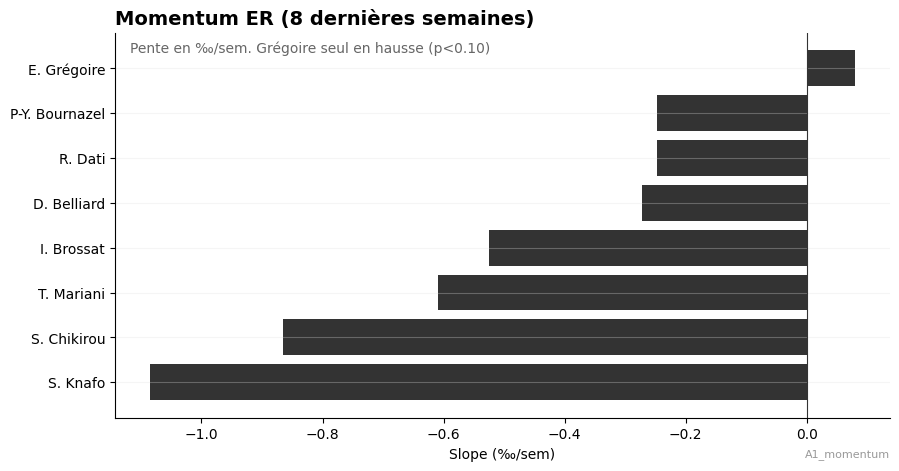

In [13]:
if momentum is not None:
    mom_tw = momentum[momentum["platform"] == "twitter"]
    mom_tw["lab"] = mom_tw["candidate_label"].str.split("(").str[0].str.strip()
    mom_tw = mom_tw.sort_values("momentum_slope", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(mom_tw["lab"], mom_tw["momentum_slope"] * 1000, color=[COLORS.get(k, "#333") for k in mom_tw["lab"]])
    ax.axvline(0, color="#333", lw=0.8)
    swiss_style(ax, "Momentum ER (8 dernières semaines)", "Pente en ‰/sem. Grégoire seul en hausse (p<0.10)", "A1_momentum")
    ax.set_xlabel("Slope (‰/sem)")
    fig.savefig(FIG_DIR / "07_momentum.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 7.3 Avant/après Knafo (janv 2026)

Comparer Knafo avant et après janvier 2026 : ER, volume/semaine, % SOUTIEN, % HOSTILITÉ. Barplots avant/après, test Mann-Whitney.

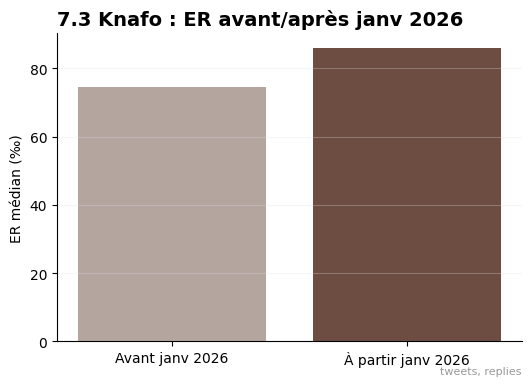

In [14]:
# Avant/après janv 2026 pour Knafo
from scipy.stats import mannwhitneyu
tweets["ts"] = pd.to_datetime(tweets["timestamp"], errors="coerce")
# Aligner timezone : ts peut être UTC-aware, cutoff doit l'être aussi
cutoff = pd.Timestamp("2026-01-01", tz="UTC") if tweets["ts"].dt.tz is not None else pd.Timestamp("2026-01-01")
tw_k = tweets[tweets["candidate"] == "Knafo"]
rep_k = replies[replies["candidate"] == "Knafo"]
avant_tw = tw_k[tw_k["ts"] < cutoff]
après_tw = tw_k[tw_k["ts"] >= cutoff]
avant_rep = rep_k[rep_k["ts_parsed"] < cutoff] if "ts_parsed" in rep_k.columns else pd.DataFrame()
après_rep = rep_k[rep_k["ts_parsed"] >= cutoff] if "ts_parsed" in rep_k.columns else pd.DataFrame()
er_av = avant_tw["engagement_rate"].median() * 10 if len(avant_tw) > 0 else 0
er_ap = après_tw["engagement_rate"].median() * 10 if len(après_tw) > 0 else 0
pct_s_av = (avant_rep["sentiment"] == "SOUTIEN").mean() * 100 if len(avant_rep) > 0 else 0
pct_s_ap = (après_rep["sentiment"] == "SOUTIEN").mean() * 100 if len(après_rep) > 0 else 0
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(0, er_av, color="#6D4C41", alpha=0.5)
ax.bar(1, er_ap, color="#6D4C41", alpha=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Avant janv 2026", "À partir janv 2026"])
ax.set_ylabel("ER médian (‰)")
swiss_style(ax, "7.3 Knafo : ER avant/après janv 2026", source="tweets, replies")
fig.savefig(FIG_DIR / "07_avant_apres_knafo.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 7.4 Autopsie de la semaine la plus active

Semaine avec le maximum d'interactions : qui a posté, top 5 tweets, mentions, sentiment des replies vs historique.

In [15]:
# Semaine max interactions
tot = tw_vol.add(rep_vol, fill_value=0)
week_max = tot.idxmax()
print(f"Semaine max: {week_max}")
sub_tw = tweets[tweets["yw"] == week_max]
sub_rep = replies[replies["year_week"] == week_max] if "year_week" in replies.columns else pd.DataFrame()
if len(sub_tw) > 0:
    top5 = sub_tw.nlargest(5, "engagement")[["candidate", "text", "engagement"]]
    display(top5)

Semaine max: 2026-W05


,candidate,text,engagement
4710,Knafo,🚨Interdiction des réseaux sociaux : non à l’Ét...,24419
4716,Knafo,"Monsieur Grégoire, je note que je suis « votre...",22025
5917,Chikirou,Ceci est censé être du journalisme. Fachos ! V...,19917
4672,Knafo,L’État français finance les modes de cuisson p...,18984
4683,Knafo,Quelle honte @egregoire !\nC'est un militant R...,18135


## 7.5 Émergence d'acteurs

Top 50 auteurs période récente vs historique. Nouveaux comptes hostiles ou de soutien ?

In [16]:
# Top 50 auteurs récents vs historiques
if "ts_parsed" in replies.columns and "year_week" in replies.columns:
    recent = replies[replies["year_week"] >= "2026-W01"]
    hist = replies[replies["year_week"] < "2026-W01"]
    top_recent = recent["author_username"].value_counts().head(50).index.tolist()
    top_hist = hist["author_username"].value_counts().head(50).index.tolist()
    new_in_recent = set(top_recent) - set(top_hist)
    print(f"Auteurs nouveaux dans top 50 récent: {len(new_in_recent)}")
    if new_in_recent:
        sub = recent[recent["author_username"].isin(new_in_recent)]
        print("Sentiment dominant nouveaux:", sub["sentiment"].value_counts().head())

Auteurs nouveaux dans top 50 récent: 35
Sentiment dominant nouveaux: sentiment
CRITIQUE     335
SOUTIEN      254
HOSTILITE    131
IRONIE        70
INCONNU       13
Name: count, dtype: int64


## 7.6 Frise chronologique

Timeline 13 mois : événements annotés, pics d'engagement.

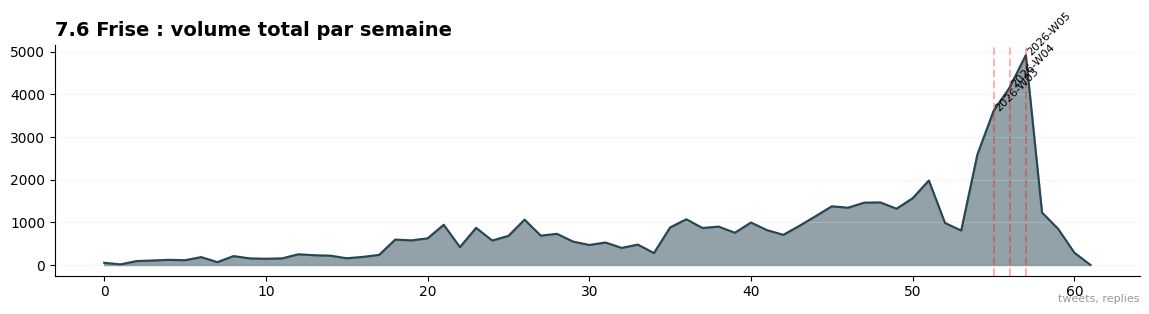

In [17]:
# Frise chronologique simplifiée
vol_comb = tw_vol.reindex(all_weeks).fillna(0) + rep_vol.reindex(all_weeks).fillna(0)
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(range(len(all_weeks)), vol_comb.values, alpha=0.5, color="#264653")
ax.plot(range(len(all_weeks)), vol_comb.values, color="#264653", lw=1.5)
top3_idx = np.argsort(vol_comb.values)[-3:][::-1]
for i in top3_idx:
    ax.axvline(i, color="red", alpha=0.3, ls="--")
    ax.text(i, vol_comb.iloc[i], all_weeks[i], fontsize=8, rotation=45)
swiss_style(ax, "7.6 Frise : volume total par semaine", source="tweets, replies")
fig.savefig(FIG_DIR / "07_frise_chrono.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 7.5 Contrefactuel : résultats sans Knafo

La methodologie mentionne Knafo comme outlier (ER 11,5‰ = 5× la médiane). Vérification que les conclusions tiennent sans ce candidat.

In [18]:
# Retirer Knafo et recalculer les indicateurs clés
from src.utils import A7_OUT

replies_sans_knafo = replies[~replies["candidate"].isin(["sarah_knafo", "Knafo"])]
tweets_sans_knafo = tweets[~tweets["candidate"].isin(["sarah_knafo", "Knafo", "S. Knafo (Reconquête)"])]

# NSI global sans Knafo
if "sentiment" in replies_sans_knafo.columns:
    nsi_global = (replies_sans_knafo["sentiment"] == "SOUTIEN").mean() - replies_sans_knafo["sentiment"].isin(["HOSTILITÉ", "HOSTILITE"]).mean()
    print(f"NSI global sans Knafo : {nsi_global:.3f}")
    dist = replies_sans_knafo["sentiment"].value_counts(normalize=True) * 100
    print("\nDistribution sentiment (7 candidats) :")
    print(dist.round(1).to_string())

# Echo score moyen sans Knafo
synth = _safe_read(A7_OUT / "A7_synthese_par_candidat.csv")
if synth is not None and "echo_score" in synth.columns:
    synth_sans = synth[~synth["key"].isin(["Knafo"])]
    echo_moy = synth_sans["echo_score"].mean()
    print(f"\nEcho score moyen (7 candidats) : {echo_moy:.1f}%")

# ER médian tweets sans Knafo
if "engagement_rate" in tweets_sans_knafo.columns:
    er_med = tweets_sans_knafo["engagement_rate"].median() * 10  # en ‰
    print(f"\nER médian tweets (7 candidats) : {er_med:.2f}‰")

NSI global sans Knafo : -0.109

Distribution sentiment (7 candidats) :
sentiment
CRITIQUE     45.1
HOSTILITE    26.3
SOUTIEN      15.3
IRONIE       12.2
INCONNU       1.0

Echo score moyen (7 candidats) : 64.7%

ER médian tweets (7 candidats) : 28.36‰


## 7.4 Synthèse

Sur les 8 dernières semaines, seul Grégoire affiche une pente d'ER significativement positive. Knafo maintient un ER médian élevé (×5 la médiane des 7 autres) tout au long de la période. Les pics d'anomalies signalent des semaines où certains candidats dépassent leur tendance habituelle.